/var/folders/xt/zxpvbvsx2zb75gd2395zm9000000gn/T/ipykernel_54328/3870530389.py:54: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  cx = city_shp.geometry.centroid.x
/var/folders/xt/zxpvbvsx2zb75gd2395zm9000000gn/T/ipykernel_54328/3870530389.py:55: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  cy = city_shp.geometry.centroid.y


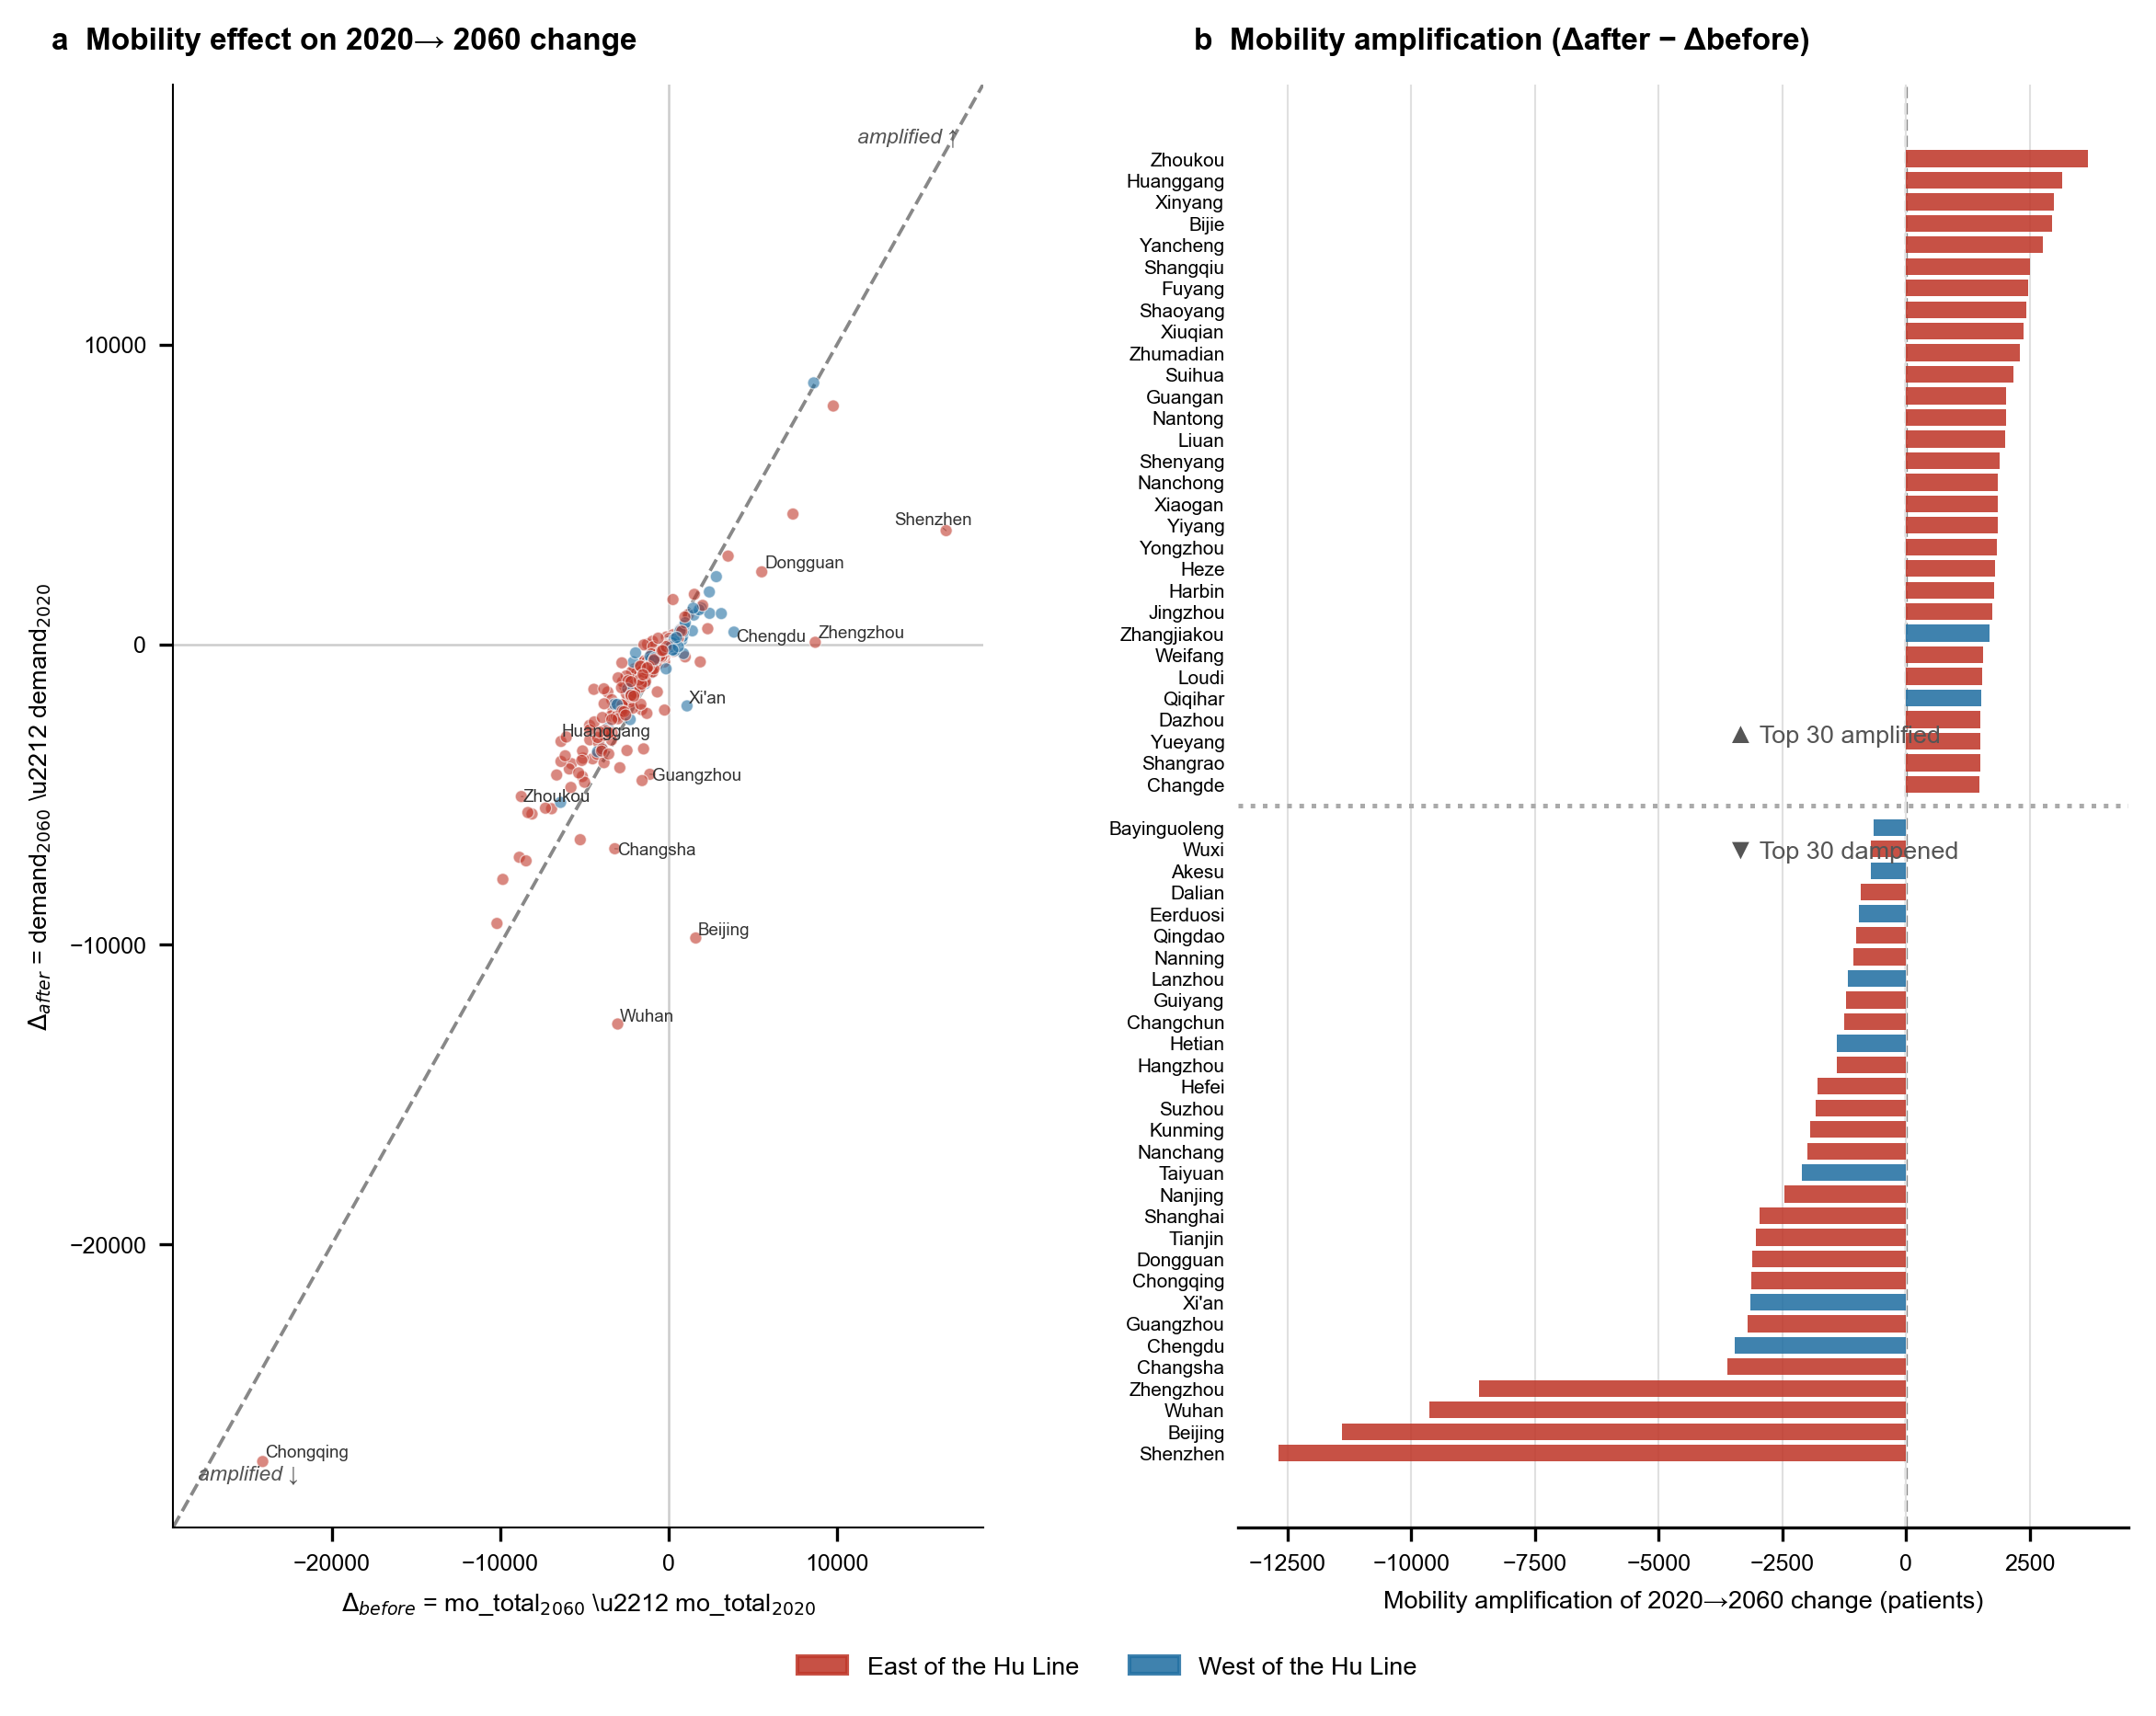

Saved → /Users/shirley/Desktop/plots_V2/Fig_mobility_change.png


In [7]:
# =============================================================================
# Fig: Mobility effect on 2020->2060 change
#   Panel A (scatter): x = Δ_before (mo_total 2060-2020), y = Δ_after (demand 2060-2020)
#                       diagonal y=x reference; colour = East/West
#   Panel B (diverging bar): (Δ_after - Δ_before), top30 / bottom30 cities
# =============================================================================

from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from adjustText import adjust_text

# ── 0. Paths & settings ───────────────────────────────────────────────────────
FLOW_DIR  = Path("/Volumes/UCL/论文工作/空气污染/cross_flow_truncated/averaged_results/flow_avg")
LOCAL_DIR = Path("/Volumes/UCL/论文工作/空气污染/health_burden/air_scenarios_5/city_patient_sum")
SHP_PATH  = Path("/Users/shirley/Library/CloudStorage/OneDrive-UniversityCollegeLondon/Desktop/city_shp/shi_en.shp")
OUTFILE   = Path("/Users/shirley/Desktop/plots_V2/Fig_mobility_change.png")
SCENARIO  = "earlypeak_NZ_CL"

CITY_NAME_MAP = {
    "Suuzhou":   "Suzhou",
    "Wulumuqi":  "Urumqi",
    "Xian":      "Xi'an",
    "Qiqihaer":  "Qiqihar",
    "Huhehaote": "Hohhot",
    "Haerbin":   "Harbin",
}

C_EAST = "#C0392B"
C_WEST = "#2471A3"

# ── 1. Global style ───────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":      "Arial",
    "font.size":        6,
    "axes.titlesize":   8,
    "axes.titleweight": "bold",
    "axes.titlepad":    2,
})

# ── 2. Region map ──────────────────────────────────────────────────────────────
HHY = {"lon": [127.5, 98.5], "lat": [50.2, 25.0]}

def hhy_lon_at_lat(lat):
    t = (lat - HHY["lat"][1]) / (HHY["lat"][0] - HHY["lat"][1])
    return HHY["lon"][1] + t * (HHY["lon"][0] - HHY["lon"][1])

city_shp = gpd.read_file(SHP_PATH)
city_shp["English"] = city_shp["English"].str.strip().map(lambda x: CITY_NAME_MAP.get(x, x))
cx = city_shp.geometry.centroid.x
cy = city_shp.geometry.centroid.y
city_shp["region"] = np.where(cx > hhy_lon_at_lat(cy), "East", "West")
region_map = (
    city_shp[["English", "region"]]
    .drop_duplicates(subset="English")
    .set_index("English")["region"]
    .to_dict()
)

# ── 3. Data loaders (same as Fig3) ───────────────────────────────────────────
def rename_idx(idx):
    return idx.str.strip().map(lambda x: CITY_NAME_MAP.get(x, x))

def load_flow_matrix(year):
    path = FLOW_DIR / f"flow_patientnum_avg_{SCENARIO}_{year}.csv"
    df   = pd.read_csv(path, index_col=0)
    df.index   = rename_idx(df.index)
    df.columns = rename_idx(df.columns)
    df = df.loc[~df.index.isin(["total"]), ~df.columns.isin(["total"])]
    np.fill_diagonal(df.values, 0)
    return df

def load_citysum(year):
    path = LOCAL_DIR / f"citysum_{SCENARIO}_{year}.csv"
    df   = pd.read_csv(path)
    df["city"] = df["city"].str.strip().map(lambda x: CITY_NAME_MAP.get(x, x))
    return df.groupby("city")[["local_patient", "mo_total"]].sum()

def compute_year(year):
    df_flow  = load_flow_matrix(year)
    df_local = load_citysum(year)
    inflow   = df_flow.sum(axis=0).groupby(level=0).sum()
    outflow  = df_flow.sum(axis=1).groupby(level=0).sum()
    all_cities = inflow.index.union(outflow.index)
    inflow   = inflow.reindex(all_cities,  fill_value=0)
    outflow  = outflow.reindex(all_cities, fill_value=0)
    net      = (inflow - outflow).rename("net")
    df_local = df_local.groupby(level=0).sum()
    common   = net.index.intersection(df_local.index)
    out      = df_local.loc[common].copy()
    out["net"]    = net.loc[common].values
    out["demand"] = out["net"] + out["local_patient"]
    return out

# ── 4. Compute 2020 vs 2060 ───────────────────────────────────────────────────
d2020 = compute_year(2020)
d2060 = compute_year(2060)

common = d2020.index.intersection(d2060.index)
df = pd.DataFrame(index=common)
df["mo_total_2020"] = d2020.loc[common, "mo_total"]
df["mo_total_2060"] = d2060.loc[common, "mo_total"]
df["demand_2020"]   = d2020.loc[common, "demand"]
df["demand_2060"]   = d2060.loc[common, "demand"]

df["delta_before"] = df["mo_total_2060"] - df["mo_total_2020"]   # x
df["delta_after"]  = df["demand_2060"]   - df["demand_2020"]     # y
df["mobility_amp"] = df["delta_after"] - df["delta_before"]      # for bar chart
df["region"] = df.index.map(region_map)

# ── 5. Layout ─────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20 / 2.54, 16 / 2.54), dpi=300, facecolor="white")
gs  = GridSpec(
    1, 2,
    figure=fig,
    width_ratios=[1, 1.1],
    wspace=0.30,
    left=0.07, right=0.97,
    top=0.93,   bottom=0.10,
)
ax_scatter = fig.add_subplot(gs[0, 0])
ax_bar     = fig.add_subplot(gs[0, 1])

# ── 6A. Scatter: delta_before vs delta_after ─────────────────────────────────
ax_scatter.text(-0.15, 1.02, "a  Mobility effect on 2020\u2192 2060 change",
                transform=ax_scatter.transAxes,
                fontsize=8, fontweight="bold", va="bottom", ha="left")

colors_s = df["region"].map({"East": C_EAST, "West": C_WEST})
ax_scatter.scatter(df["delta_before"], df["delta_after"],
                    c=colors_s, s=10, alpha=0.6,
                    edgecolors="white", linewidths=0.3, zorder=3)

# y = x reference line
lims = [
    min(df["delta_before"].min(), df["delta_after"].min()),
    max(df["delta_before"].max(), df["delta_after"].max()),
]
pad = (lims[1] - lims[0]) * 0.05
lims = [lims[0] - pad, lims[1] + pad]
ax_scatter.plot(lims, lims, color="#888", lw=0.9, ls="--", zorder=1)
ax_scatter.set_xlim(lims)
ax_scatter.set_ylim(lims)

# zero lines
ax_scatter.axhline(0, color="#CCC", lw=0.6, zorder=0)
ax_scatter.axvline(0, color="#CCC", lw=0.6, zorder=0)

ax_scatter.set_xlabel(r"$\Delta_{before}$ = mo_total$_{2060}$ \u2212 mo_total$_{2020}$",
                      fontsize=6.5)
ax_scatter.set_ylabel(r"$\Delta_{after}$ = demand$_{2060}$ \u2212 demand$_{2020}$",
                      fontsize=6.5)
ax_scatter.tick_params(labelsize=6)
ax_scatter.spines[["top", "right"]].set_visible(False)
ax_scatter.spines[["bottom", "left"]].set_linewidth(0.5)

# annotate the most extreme cities (largest |mobility_amp|)
top_extreme = df.reindex(df["mobility_amp"].abs().sort_values(ascending=False).index).head(12)
texts = []
for city, row in top_extreme.iterrows():
    t = ax_scatter.text(row["delta_before"], row["delta_after"], city,
                        fontsize=4.5, color="#333", zorder=5)
    texts.append(t)
if texts:
    adjust_text(texts, ax=ax_scatter, time_lim=1,
                arrowprops=dict(arrowstyle="-", color="#999", lw=0.3))

# quadrant annotation
ax_scatter.text(0.97, 0.97, "amplified ↑", transform=ax_scatter.transAxes,
                fontsize=5.5, color="#555", ha="right", va="top", style="italic")
ax_scatter.text(0.03, 0.03, "amplified ↓", transform=ax_scatter.transAxes,
                fontsize=5.5, color="#555", ha="left", va="bottom", style="italic")

# ── 6B. Diverging bar: mobility_amp (top30 + bottom30) ───────────────────────
ax_bar.text(-0.05, 1.02, "b  Mobility amplification (\u0394after \u2212 \u0394before)",
            transform=ax_bar.transAxes,
            fontsize=8, fontweight="bold", va="bottom", ha="left")

df_sorted = df.sort_values("mobility_amp", ascending=False)
top30 = df_sorted.head(30)
bot30 = df_sorted.tail(30)

gap_row = pd.DataFrame({col: [np.nan] for col in df_sorted.columns}, index=[""])
df_b = pd.concat([top30, gap_row, bot30])

n_b = len(df_b)
y_b = np.arange(n_b)
colors_b = [
    C_EAST if r == "East" else (C_WEST if r == "West" else "#FFFFFF")
    for r in df_b["region"]
]
ax_bar.barh(y_b, df_b["mobility_amp"].values,
            color=colors_b, height=0.78, alpha=0.88, zorder=2)
ax_bar.set_yticks(y_b)
ax_bar.set_yticklabels(df_b.index, fontsize=5)
ax_bar.axvline(0, color="#888", lw=0.8, ls="--", zorder=1)
ax_bar.axhline(30, color="#AAAAAA", lw=1.2, ls=":", zorder=3)

ax_bar.text(0.55, 1 - 28/n_b, "▲ Top 30 amplified", fontsize=6.5,
            color="#555", ha="left", va="bottom", transform=ax_bar.transAxes)
ax_bar.text(0.55, 1 - 32/n_b, "▼ Top 30 dampened", fontsize=6.5,
            color="#555", ha="left", va="top", transform=ax_bar.transAxes)

ax_bar.set_xlabel("Mobility amplification of 2020\u21922060 change (patients)",
                  fontsize=6.5)
ax_bar.spines[["top", "right", "left"]].set_visible(False)
ax_bar.tick_params(axis="y", length=0, labelsize=5)
ax_bar.tick_params(axis="x", labelsize=6)
ax_bar.grid(axis="x", color="#E0E0E0", lw=0.5, zorder=0)
ax_bar.set_facecolor("white")
ax_bar.invert_yaxis()

# ── 7. Shared legend ──────────────────────────────────────────────────────────
patch_e = mpatches.Patch(color=C_EAST, label="East of the Hu Line", alpha=0.88)
patch_w = mpatches.Patch(color=C_WEST, label="West of the Hu Line", alpha=0.88)
fig.legend(handles=[patch_e, patch_w], loc="lower center", ncol=2,
           fontsize=6.5, frameon=False, bbox_to_anchor=(0.5, 0.0))

# ── 8. Save ───────────────────────────────────────────────────────────────────
OUTFILE.parent.mkdir(parents=True, exist_ok=True)
#fig.savefig(OUTFILE, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved → {OUTFILE}")